In [1]:
import pandas as pd

# Load raw data
fraud_df = pd.read_csv("../data/raw/Fraud_Data.csv")
ip_country_df = pd.read_csv("../data/raw/IpAddress_to_Country.csv")
credit_df = pd.read_csv("../data/raw/creditcard.csv")

# Quick overview
print("Fraud Data:")
display(fraud_df.head())

print("\nIP to Country Mapping:")
display(ip_country_df.head())

print("\nCredit Card Data:")
display(credit_df.head())


Fraud Data:


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0



IP to Country Mapping:


,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0,16777471,Australia
1,16777472.0,16777727,China
2,16777728.0,16778239,China
3,16778240.0,16779263,Australia
4,16779264.0,16781311,China



Credit Card Data:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
# Check missing values
print("Missing Values in Fraud_Data:")
print(fraud_df.isnull().sum())

print("\nMissing Values in Credit Card Data:")
print(credit_df.isnull().sum())

print("\nMissing Values in IP-Country Mapping:")
print(ip_country_df.isnull().sum())

# Check for duplicates
print("\nDuplicates in Fraud_Data:", fraud_df.duplicated().sum())
print("Duplicates in Credit Card Data:", credit_df.duplicated().sum())
print("Duplicates in IP-Country Mapping:", ip_country_df.duplicated().sum())


Missing Values in Fraud_Data:
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

Missing Values in Credit Card Data:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Missing Values in IP-Country Mapping:
lower_bound_ip_address    0
upper_bound_ip_address    0
country                   0
dtype: int64

Duplicates in Fraud_Data: 0
Duplicates in Credit Card Data: 1081
Duplicates in IP-Country Mapping: 0


In [3]:
# Convert to datetime
fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])

In [4]:
display(fraud_df.info())
display(credit_df.info())
display(ip_country_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[ns]
 2   purchase_time   151112 non-null  datetime64[ns]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  object        
 5   source          151112 non-null  object        
 6   browser         151112 non-null  object        
 7   sex             151112 non-null  object        
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  float64       
 10  class           151112 non-null  int64         
dtypes: datetime64[ns](2), float64(1), int64(4), object(4)
memory usage: 12.7+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138846 entries, 0 to 138845
Data columns (total 3 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   lower_bound_ip_address  138846 non-null  float64
 1   upper_bound_ip_address  138846 non-null  int64  
 2   country                 138846 non-null  object 
dtypes: float64(1), int64(1), object(1)
memory usage: 3.2+ MB


None

In [5]:
credit_df = credit_df.drop_duplicates()

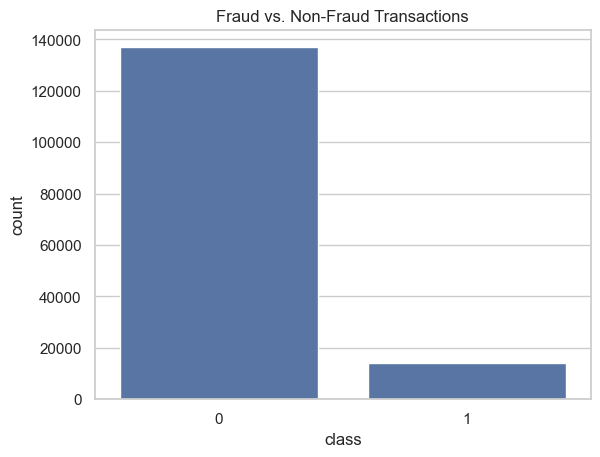

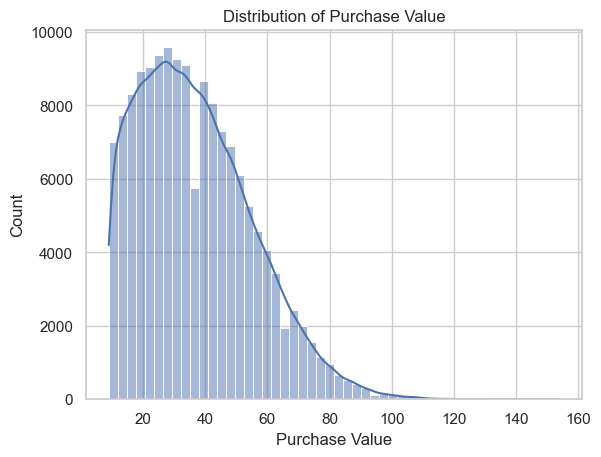

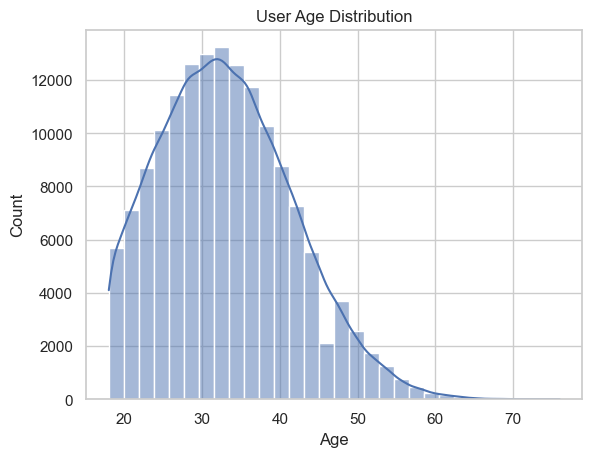

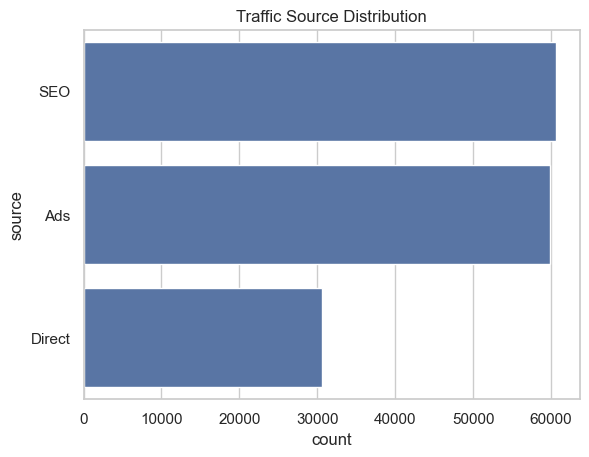

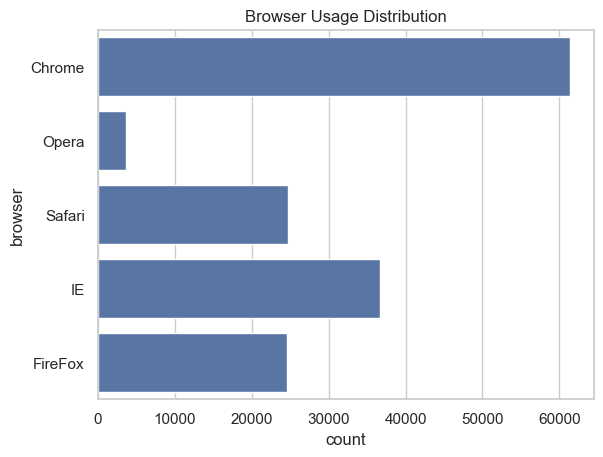

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

## Univariate Analysis

# Set style
sns.set(style="whitegrid")

# Target distribution
sns.countplot(x="class", data=fraud_df)
plt.title("Fraud vs. Non-Fraud Transactions")
plt.show()

# Purchase value distribution
sns.histplot(fraud_df["purchase_value"], bins=50, kde=True)
plt.title("Distribution of Purchase Value")
plt.xlabel("Purchase Value")
plt.show()

# Age distribution
sns.histplot(fraud_df["age"], bins=30, kde=True)
plt.title("User Age Distribution")
plt.xlabel("Age")
plt.show()

# Source
sns.countplot(y="source", data=fraud_df)
plt.title("Traffic Source Distribution")
plt.show()

# Browser
sns.countplot(y="browser", data=fraud_df)
plt.title("Browser Usage Distribution")
plt.show()


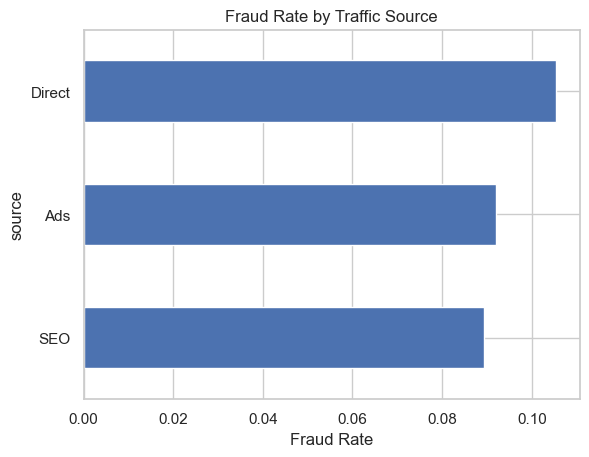

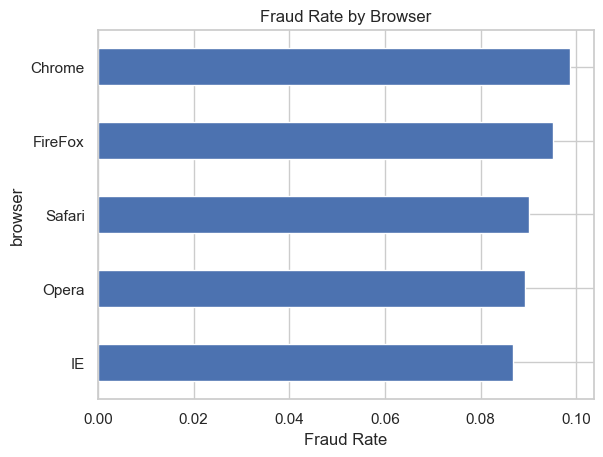

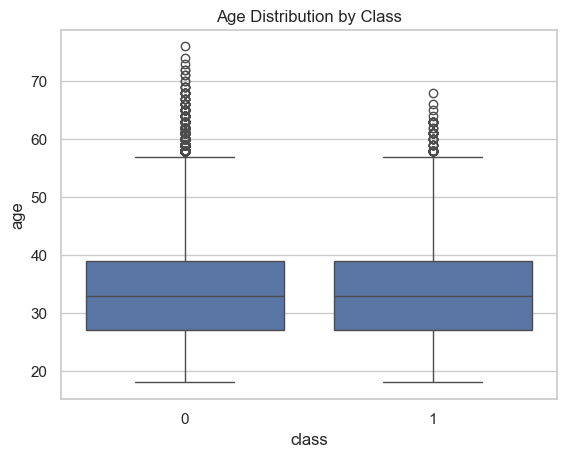

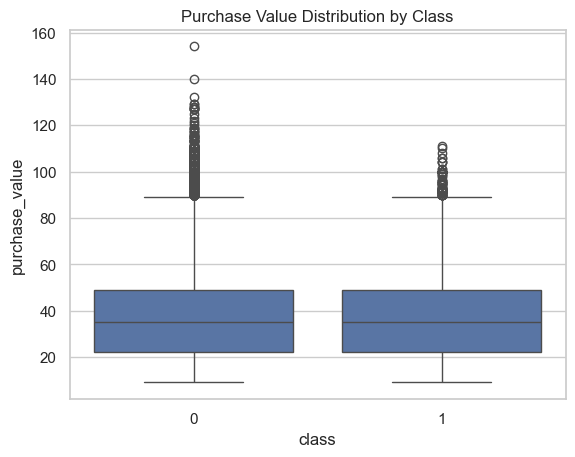

In [7]:
## Bivariate analysis

# Fraud rate by source
fraud_rate_by_source = fraud_df.groupby("source")["class"].mean().sort_values()
fraud_rate_by_source.plot(kind="barh", title="Fraud Rate by Traffic Source")
plt.xlabel("Fraud Rate")
plt.show()

# Fraud rate by browser
fraud_rate_by_browser = fraud_df.groupby("browser")["class"].mean().sort_values()
fraud_rate_by_browser.plot(kind="barh", title="Fraud Rate by Browser")
plt.xlabel("Fraud Rate")
plt.show()

# Age vs Fraud
sns.boxplot(x="class", y="age", data=fraud_df)
plt.title("Age Distribution by Class")
plt.show()

# Purchase value vs Fraud
sns.boxplot(x="class", y="purchase_value", data=fraud_df)
plt.title("Purchase Value Distribution by Class")
plt.show()


In [8]:
ip_country_df["lower_bound_ip_address"] = ip_country_df["lower_bound_ip_address"].astype(int)
fraud_df["ip_int"] = fraud_df["ip_address"].astype(int)

In [9]:
display(fraud_df.info())
display(ip_country_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[ns]
 2   purchase_time   151112 non-null  datetime64[ns]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  object        
 5   source          151112 non-null  object        
 6   browser         151112 non-null  object        
 7   sex             151112 non-null  object        
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  float64       
 10  class           151112 non-null  int64         
 11  ip_int          151112 non-null  int32         
dtypes: datetime64[ns](2), float64(1), int32(1), int64(4), object(4)
memory usage: 13.3+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138846 entries, 0 to 138845
Data columns (total 3 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   lower_bound_ip_address  138846 non-null  int32 
 1   upper_bound_ip_address  138846 non-null  int64 
 2   country                 138846 non-null  object
dtypes: int32(1), int64(1), object(1)
memory usage: 2.6+ MB


None

In [10]:
ip_country_df.rename(columns={
    "lower_bound_ip_address": "lower_int",
    "upper_bound_ip_address": "upper_int"
}, inplace=True)

In [11]:
# Sort both dataframes
fraud_df_sorted = fraud_df.sort_values("ip_int")
ip_country_sorted = ip_country_df.sort_values("lower_int")

# Perform the merge
merged_df = pd.merge_asof(
    fraud_df_sorted,
    ip_country_sorted,
    left_on="ip_int",
    right_on="lower_int",
    direction="backward"
)

# Filter only matches where ip_int is within the upper bound
merged_df = merged_df[merged_df["ip_int"] <= merged_df["upper_int"]]


In [12]:
merged_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,ip_int,lower_int,upper_int,country
0,138208,2015-06-10 07:02:20,2015-07-21 02:03:53,20,ZINIADFCLHYPG,Direct,IE,M,38,4.103825e+09,0,-2147483648,-2147483648,3758096127,Singapore
1,329438,2015-02-07 20:36:48,2015-02-28 21:43:52,18,QSHYBRYJBNKMU,SEO,IE,M,24,3.283051e+09,0,-2147483648,-2147483648,3758096127,Singapore
2,319411,2015-01-08 11:11:50,2015-03-06 23:37:00,36,CJHWRXISOAYTL,SEO,IE,M,48,2.970766e+09,0,-2147483648,-2147483648,3758096127,Singapore
3,24894,2015-01-07 05:59:11,2015-01-07 05:59:12,35,NWREMPUXZSXWE,SEO,FireFox,F,46,2.503225e+09,1,-2147483648,-2147483648,3758096127,Singapore
4,368181,2015-02-28 18:28:52,2015-03-06 16:32:41,35,HNQIPDXVRNDZU,Direct,Chrome,M,29,3.902230e+09,0,-2147483648,-2147483648,3758096127,Singapore


In [13]:
# Extract hour of day and day of week from purchase_time
fraud_df["hour_of_day"] = fraud_df["purchase_time"].dt.hour
fraud_df["day_of_week"] = fraud_df["purchase_time"].dt.dayofweek  # Monday=0, Sunday=6

# Calculate time difference between signup and purchase in seconds
fraud_df["time_since_signup"] = (fraud_df["purchase_time"] - fraud_df["signup_time"]).dt.total_seconds()


In [14]:
# Sort by user and purchase time
fraud_df = fraud_df.sort_values(by=["user_id", "purchase_time"])

# Calculate time since previous transaction per user (in seconds)
fraud_df["time_since_last_transaction"] = fraud_df.groupby("user_id")["purchase_time"].diff().dt.total_seconds()



In [15]:
# First, sort by user_id and purchase_time
fraud_df = fraud_df.sort_values(by=["user_id", "purchase_time"])

# Create a temporary DataFrame for rolling calc
temp_df = fraud_df.set_index("purchase_time")

# Compute rolling count of transactions in the past 24h per user
transactions_last_24h = (
    temp_df.groupby("user_id")["user_id"]
    .rolling("24h")
    .count()
    .reset_index(level=0, drop=True)
)

# Assign it back to the main DataFrame
fraud_df["transactions_last_24h"] = transactions_last_24h.values


In [16]:
fraud_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,ip_int,hour_of_day,day_of_week,time_since_signup,time_since_last_transaction,transactions_last_24h
116708,2,2015-01-11 03:47:13,2015-02-21 10:03:37,54,FGBQNDNBETFJJ,SEO,Chrome,F,25,8.802175e+08,0,880217484,10,5,3564984.0,NaN,1.0
15108,4,2015-06-02 16:40:57,2015-09-26 21:32:16,41,MKFUIVOHLJBYN,Direct,Safari,F,38,2.785906e+09,0,-2147483648,21,5,10039879.0,NaN,1.0
46047,8,2015-05-28 07:53:06,2015-08-13 11:53:07,47,SCQGQALXBUQZJ,SEO,Chrome,M,25,3.560567e+08,0,356056736,11,3,6667201.0,NaN,1.0
67650,9,2015-05-16 15:58:32,2015-05-20 23:06:42,62,IEZOHXPZBIRTE,SEO,FireFox,M,21,7.591047e+08,0,759104706,23,2,371290.0,NaN,1.0
109067,12,2015-01-10 06:25:12,2015-03-04 20:56:37,35,MSNWCFEHKTIOY,Ads,Safari,M,19,2.985180e+09,0,-2147483648,20,2,4631485.0,NaN,1.0


In [17]:
fraud_df["is_first_transaction"] = fraud_df.groupby("user_id")["purchase_time"].cumcount() == 0
fraud_df["time_since_last_transaction"] = (
    fraud_df.groupby("user_id")["purchase_time"]
    .diff()
    .dt.total_seconds()
    .fillna(999999)
)


In [18]:
fraud_df["class"].value_counts(normalize=True)

class
0    0.906354
1    0.093646
Name: proportion, dtype: float64

In [19]:
from sklearn.model_selection import train_test_split

X = fraud_df.drop("class", axis=1)
y = fraud_df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [20]:
categorical_cols = X.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"{col}: {X[col].nunique()} unique values")


device_id: 137956 unique values
source: 3 unique values
browser: 5 unique values
sex: 2 unique values


In [21]:
X_train = X_train.drop(columns=["device_id"])
X_test = X_test.drop(columns=["device_id"])


In [22]:
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Align columns
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

In [27]:
X_train_encoded = X_train_encoded.drop(columns=["signup_time","purchase_time"])

In [35]:
X_test_encoded = X_test_encoded.drop(columns=["signup_time","purchase_time"])

In [28]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_encoded, y_train)


In [ ]:
X_resampled.to_csv('../data/processed/resampled_training_data_X.csv', index=False)
y_resampled.to_csv('../data/processed/resampled_training_data_y.csv', index=False)



In [38]:
X_test_encoded.to_csv('../data/processed/test_data_X.csv', index=False)
y_test.to_csv('../data/processed/test_data_y.csv', index=False)